# Bitcoin Cryptocurrency Market

Explore the historical cryptocurrency data for market growth, Bitcoin's relative size, volatility, correlation, seasonality, and a simple baseline forecast.

The bundled Kaggle-derived archive contains daily prices through 2021. This notebook is a learning exercise: its historical analyses and baseline forecast are not reliable predictions or investment advice.

## 1. Load and inspect the data

The CSV files are read directly from the challenge ZIP. The path lookup works when the notebook is opened from the repository root or from this solution folder.

In [ ]:
from pathlib import Path
from zipfile import ZipFile

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

archive_candidates = [
    parent / "challenges" / "cryptoanalisis" / "crypto.zip"
    for parent in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
]
archive_path = next((path for path in archive_candidates if path.is_file()), None)
if archive_path is None:
    raise FileNotFoundError(
        "Could not find challenges/cryptoanalisis/crypto.zip. "
        "Open this notebook from within the repository."
    )

frames = []
with ZipFile(archive_path) as archive:
    csv_paths = sorted(
        name for name in archive.namelist()
        if name.startswith("coin_") and name.endswith(".csv")
    )
    for csv_path in csv_paths:
        coin = Path(csv_path).stem.removeprefix("coin_")
        with archive.open(csv_path) as csv_file:
            frame = pd.read_csv(csv_file)
        frame["Date"] = pd.to_datetime(frame["Date"], utc=True).dt.tz_localize(None)
        for column in ["Open", "High", "Low", "Close", "Volume", "Marketcap"]:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")
        frame["Coin"] = coin
        frames.append(frame)

market = pd.concat(frames, ignore_index=True).sort_values(["Date", "Coin"])
market = market.dropna(subset=["Date", "Close", "Marketcap"])

print(f"Archive: {archive_path}")
print(f"Currencies: {market['Coin'].nunique()} | Rows: {len(market):,}")
print(f"Date range: {market['Date'].min():%Y-%m-%d} to {market['Date'].max():%Y-%m-%d}")
display(market.groupby("Coin").agg(
    first_date=("Date", "min"),
    last_date=("Date", "max"),
    observations=("Date", "size"),
).sort_values("observations", ascending=False).head(10))

Archive: C:\Users\Umesh Chandra\Infomagnus-projects\GH\challenges\CopilotHackathon\challenges\cryptoanalisis\crypto.zip
Currencies: 23 | Rows: 37,082
Date range: 2013-04-29 to 2021-07-06


,first_date,last_date,observations
Coin,,,
Bitcoin,2013-04-29 23:59:59,2021-07-06 23:59:59,2991
Litecoin,2013-04-29 23:59:59,2021-07-06 23:59:59,2991
XRP,2013-08-05 23:59:59,2021-07-06 23:59:59,2893
Dogecoin,2013-12-16 23:59:59,2021-07-06 23:59:59,2760
Monero,2014-05-22 23:59:59,2021-07-06 23:59:59,2602
Stellar,2014-08-06 23:59:59,2021-07-06 23:59:59,2527
Tether,2015-02-26 23:59:59,2021-07-06 23:59:59,2318
NEM,2015-04-02 23:59:59,2021-07-06 23:59:59,2288
Ethereum,2015-08-08 23:59:59,2021-07-06 23:59:59,2160


## 2. How did prices and market capitalizations change?

Prices are indexed to 100 at each currency's first available observation so their relative growth can be compared despite different starting prices. Market capitalization is shown in dollars on a logarithmic scale because the currencies differ greatly in size.

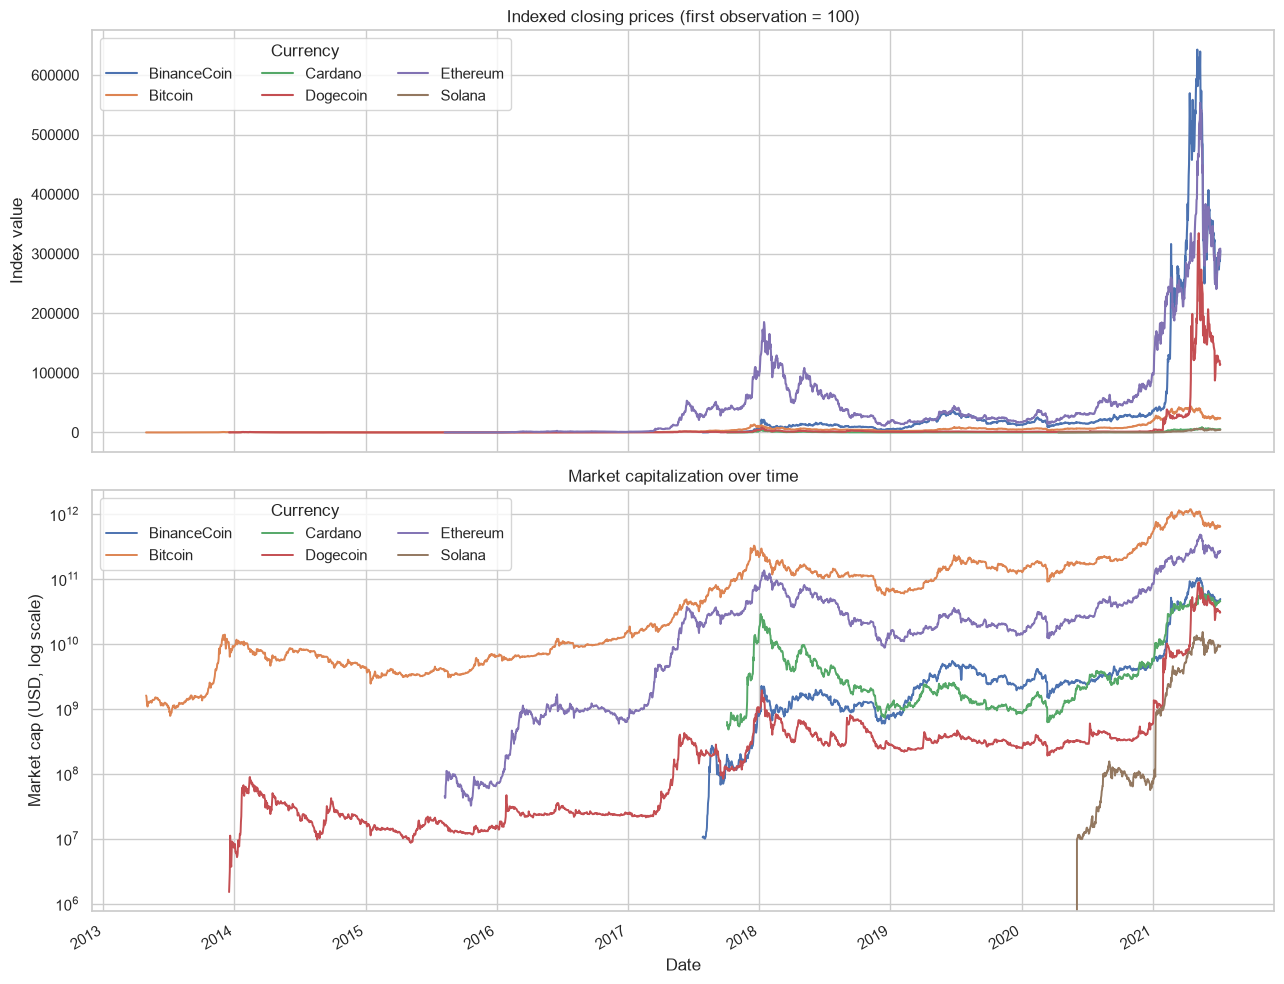

,Date,Close,Marketcap
Coin,,,
Bitcoin,2021-07-06 23:59:59,34235.193451,6.418992e+11
Ethereum,2021-07-06 23:59:59,2324.679449,2.710286e+11
Tether,2021-07-06 23:59:59,1.000090,6.233384e+10
BinanceCoin,2021-07-06 23:59:59,320.934802,4.924196e+10
Cardano,2021-07-06 23:59:59,1.418053,4.530158e+10
XRP,2021-07-06 23:59:59,0.665402,3.072284e+10
Dogecoin,2021-07-06 23:59:59,0.234422,3.055252e+10
USDCoin,2021-07-06 23:59:59,1.000059,2.567322e+10
Polkadot,2021-07-06 23:59:59,16.143564,1.546772e+10


In [ ]:
focus_coins = ["Bitcoin", "Ethereum", "BinanceCoin", "Cardano", "Dogecoin", "Solana"]
price_data = market[market["Coin"].isin(focus_coins)]
price_wide = price_data.pivot_table(index="Date", columns="Coin", values="Close", aggfunc="last")
price_index = price_wide.divide(price_wide.bfill().iloc[0]).mul(100)

fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)
price_index.plot(ax=axes[0], linewidth=1.5)
axes[0].set(title="Indexed closing prices (first observation = 100)", ylabel="Index value")
axes[0].legend(title="Currency", ncol=3)

cap_wide = price_data.pivot_table(index="Date", columns="Coin", values="Marketcap", aggfunc="last")
cap_wide.plot(ax=axes[1], linewidth=1.4)
axes[1].set_yscale("log")
axes[1].set(title="Market capitalization over time", ylabel="Market cap (USD, log scale)", xlabel="Date")
axes[1].legend(title="Currency", ncol=3)
plt.tight_layout()
plt.show()

latest_cap = market.sort_values("Date").groupby("Coin").tail(1).nlargest(10, "Marketcap")
display(latest_cap[["Coin", "Date", "Close", "Marketcap"]].set_index("Coin"))

## 3. How large is Bitcoin within this dataset?

This is Bitcoin's share of the market capitalization represented by these 23 dataset files on each date. It is **not** the share of every cryptocurrency in the real-world market, because the archive contains only a selected set of currencies.

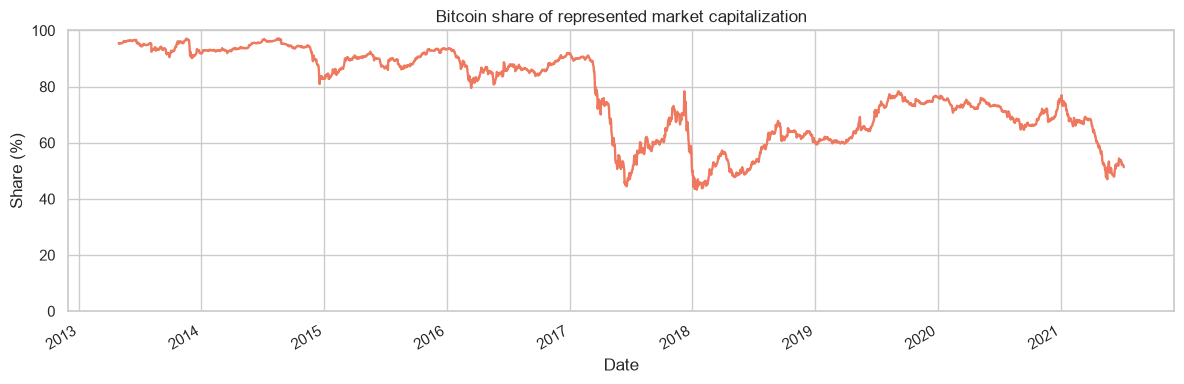

First available share: 95.5% on 2013-04-29
Last available share:  51.3% on 2021-07-06


In [ ]:
cap_by_date = market.pivot_table(index="Date", columns="Coin", values="Marketcap", aggfunc="sum")
represented_cap = cap_by_date.sum(axis=1, min_count=1)
bitcoin_share = cap_by_date["Bitcoin"].div(represented_cap).mul(100).dropna()

ax = bitcoin_share.plot(color="#ef795e", linewidth=1.7, figsize=(12, 4))
ax.set(title="Bitcoin share of represented market capitalization", ylabel="Share (%)", xlabel="Date")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

print(f"First available share: {bitcoin_share.iloc[0]:.1f}% on {bitcoin_share.index[0]:%Y-%m-%d}")
print(f"Last available share:  {bitcoin_share.iloc[-1]:.1f}% on {bitcoin_share.index[-1]:%Y-%m-%d}")

## 4. Which currencies are volatile or relatively stable?

Daily log-return standard deviation is annualized using 365 days, matching a market that trades every day. This is a descriptive measure of historical price variation, not a measure of safety. Stablecoins and short-history coins should be interpreted cautiously.

,Annualized log-return volatility,Observations
Coin,,
Solana,1.779985,451
Uniswap,1.691999,291
Aave,1.647774,274
Tron,1.616429,1391
Polkadot,1.606633,319
Dogecoin,1.600191,2759
ChainLink,1.506476,1384
NEM,1.501648,2287
BinanceCoin,1.431800,1441


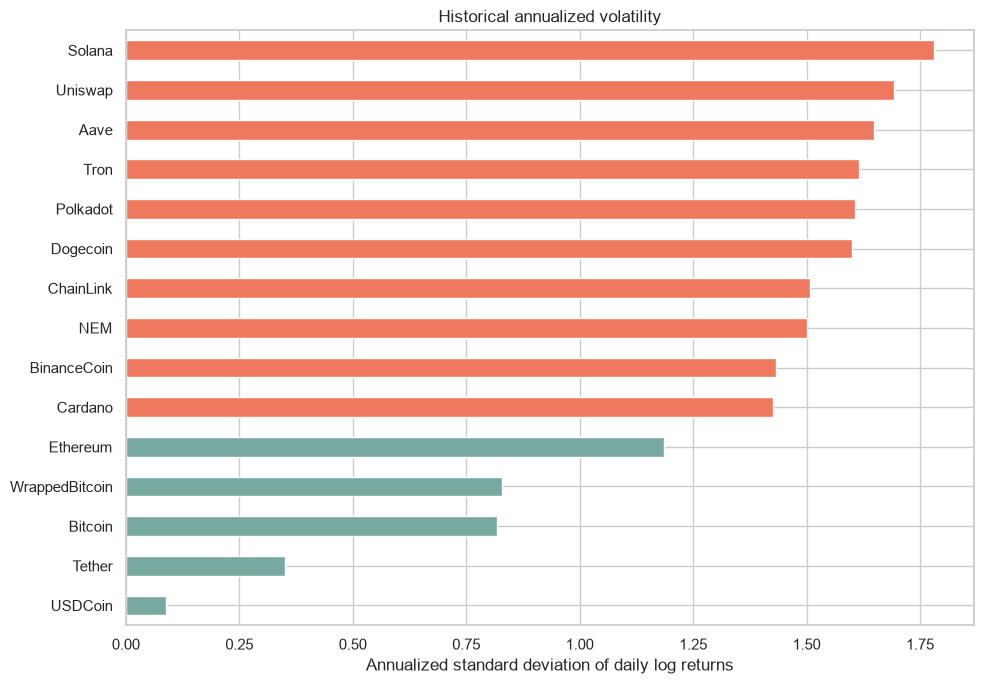

In [ ]:
import numpy as np

market = market.sort_values(["Coin", "Date"]).copy()
previous_close = market.groupby("Coin")["Close"].shift(1)
valid_prices = (market["Close"] > 0) & (previous_close > 0)
daily_ratio = (market["Close"] / previous_close).where(valid_prices)
market["LogReturn"] = np.log(daily_ratio)

volatility = (market.groupby("Coin")["LogReturn"].std() * np.sqrt(365)).dropna().sort_values(ascending=False)
volatility_table = volatility.rename("Annualized log-return volatility").to_frame()
volatility_table["Observations"] = market.groupby("Coin")["LogReturn"].count()
display(volatility_table.head(10))

plot_volatility = pd.concat([volatility.head(10), volatility.tail(5)]).sort_values()
bar_colors = ["#ef795e" if coin in volatility.head(10).index else "#78a9a0" for coin in plot_volatility.index]
ax = plot_volatility.plot.barh(color=bar_colors, figsize=(10, 7))
ax.set(title="Historical annualized volatility", xlabel="Annualized standard deviation of daily log returns", ylabel="")
plt.tight_layout()
plt.show()

## 5. How do daily returns move together?

The correlation matrix compares daily log returns, not price levels. Pairwise correlations use dates where both currencies have observations, so coverage and overlapping history affect the sample.

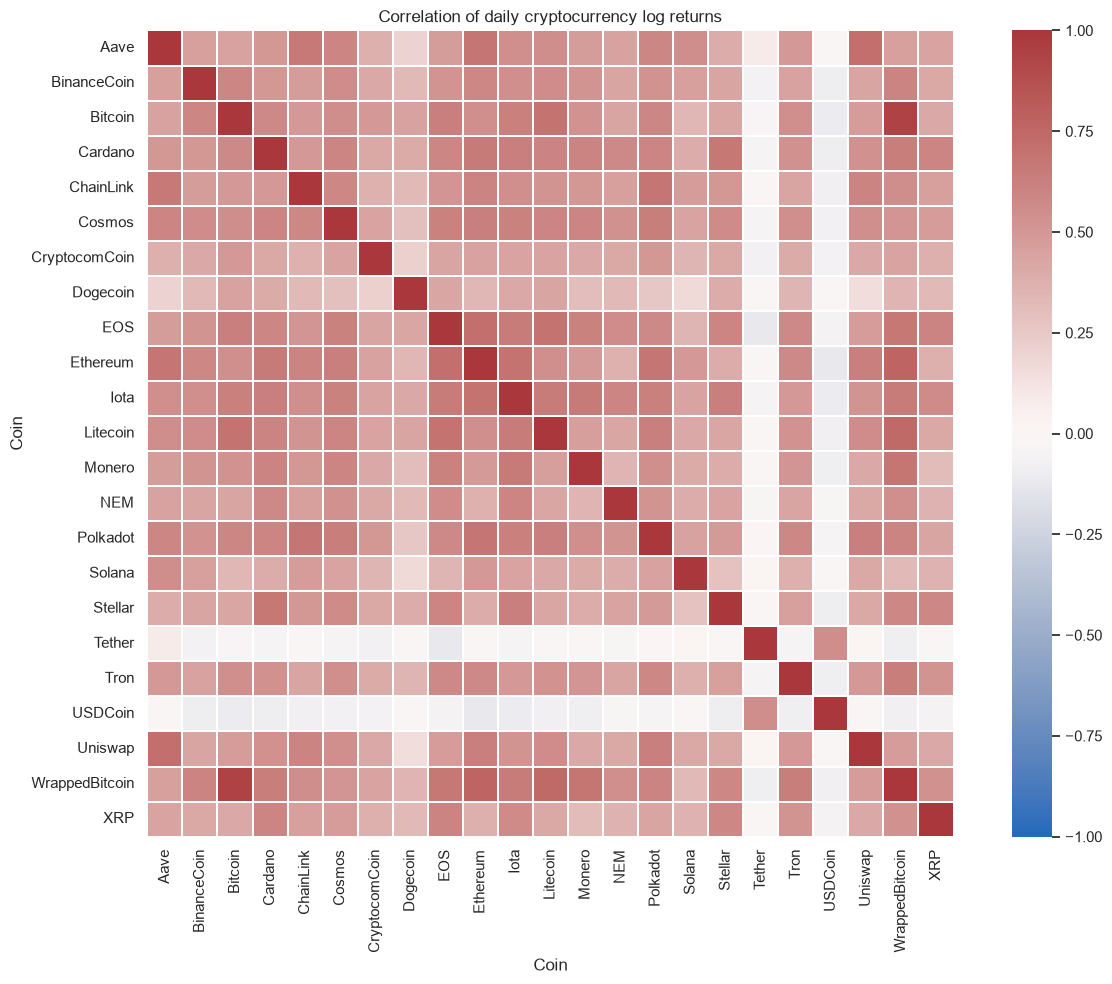

,Correlation with Bitcoin returns
Coin,
WrappedBitcoin,0.937805
Litecoin,0.688803
EOS,0.631445
Iota,0.624492
BinanceCoin,0.590287
Polkadot,0.589032
Cardano,0.574632
Cosmos,0.550382
Ethereum,0.544485


In [ ]:
return_wide = market.pivot_table(index="Date", columns="Coin", values="LogReturn", aggfunc="last")
correlation = return_wide.corr(min_periods=60)

plt.figure(figsize=(13, 10))
sns.heatmap(correlation, cmap="vlag", center=0, vmin=-1, vmax=1, square=True, linewidths=0.25)
plt.title("Correlation of daily cryptocurrency log returns")
plt.tight_layout()
plt.show()

bitcoin_correlations = correlation["Bitcoin"].drop("Bitcoin").sort_values(ascending=False)
display(bitcoin_correlations.rename("Correlation with Bitcoin returns").to_frame())

## 6. Is there a seasonal pattern?

This chart shows median monthly returns by calendar month for the selected currencies. Medians reduce the influence of extreme single-month moves, but a pattern in this historical sample is not evidence that it will repeat.

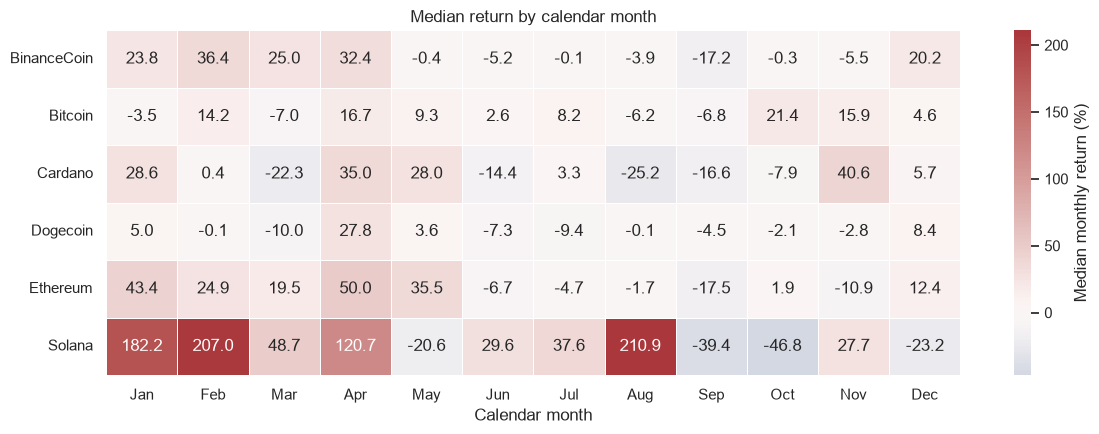

In [ ]:
monthly_close = market.groupby("Coin").resample("ME", on="Date")["Close"].last().dropna()
monthly_return = monthly_close.groupby(level="Coin").pct_change().rename("MonthlyReturn").reset_index()
monthly_return["Month"] = monthly_return["Date"].dt.month
seasonal_coins = [coin for coin in focus_coins if coin in monthly_return["Coin"].unique()]
seasonality = monthly_return[monthly_return["Coin"].isin(seasonal_coins)].pivot_table(
    index="Coin", columns="Month", values="MonthlyReturn", aggfunc="median"
).reindex(columns=range(1, 13)).mul(100)
seasonality.columns = [pd.Timestamp(month=month, year=2000, day=1).strftime("%b") for month in seasonality.columns]

plt.figure(figsize=(12, 4.5))
sns.heatmap(seasonality, cmap="vlag", center=0, annot=True, fmt=".1f", linewidths=0.4,
            cbar_kws={"label": "Median monthly return (%)"})
plt.title("Median return by calendar month")
plt.xlabel("Calendar month")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 7. Can a simple baseline forecast future Bitcoin prices?

We use the final 90 observed Bitcoin days as a chronological test set. Two deliberately simple forecasts predict either the last training close or the training period's final 30-day mean. The evaluation tests whether these baselines are useful; it does **not** establish that either method can predict future prices.

,Forecast baseline,Mean absolute error (USD)
0,Last training close,12677.884908
1,Mean of final 30 training days,13318.300122


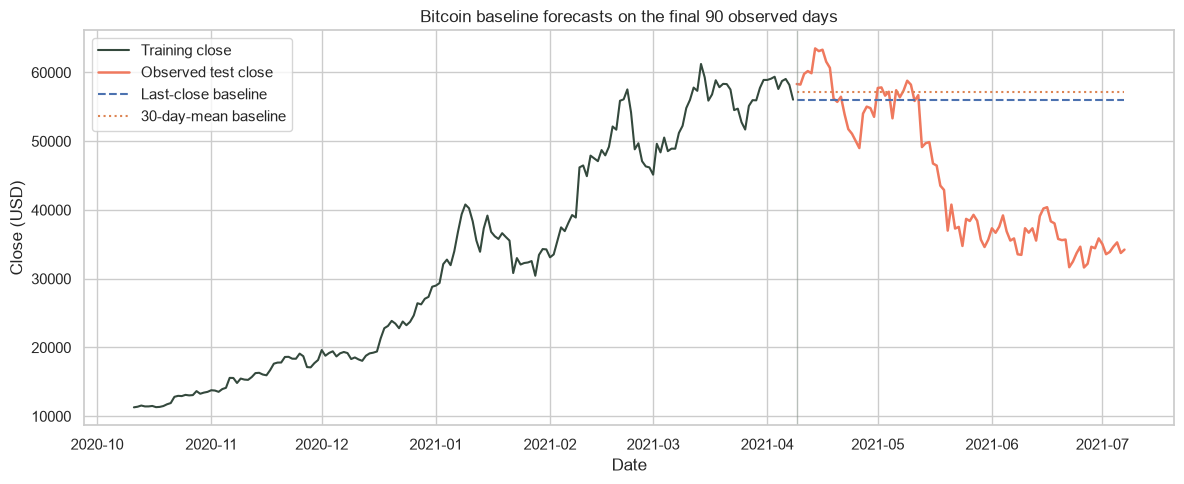

Lower holdout MAE in this window: Last training close. This is a historical comparison, not a future-price signal.


In [ ]:
bitcoin = market.loc[market["Coin"] == "Bitcoin", ["Date", "Close"]].dropna().sort_values("Date").reset_index(drop=True)
test_days = 90
if len(bitcoin) <= test_days + 30:
    raise ValueError("Not enough Bitcoin observations for the selected holdout period.")

split_at = len(bitcoin) - test_days
training = bitcoin.iloc[:split_at]
test = bitcoin.iloc[split_at:].copy()
last_close_prediction = training["Close"].iloc[-1]
mean_30d_prediction = training["Close"].tail(30).mean()
actual = test["Close"].to_numpy()
mae_last_close = np.mean(np.abs(actual - last_close_prediction))
mae_mean_30d = np.mean(np.abs(actual - mean_30d_prediction))

forecast_scores = pd.DataFrame({
    "Forecast baseline": ["Last training close", "Mean of final 30 training days"],
    "Mean absolute error (USD)": [mae_last_close, mae_mean_30d],
})
display(forecast_scores)

fig, ax = plt.subplots(figsize=(12, 5))
recent_training = training.tail(180)
ax.plot(recent_training["Date"], recent_training["Close"], label="Training close", color="#34493d")
ax.plot(test["Date"], actual, label="Observed test close", color="#ef795e", linewidth=1.8)
ax.plot(test["Date"], np.full(test_days, last_close_prediction), label="Last-close baseline", linestyle="--")
ax.plot(test["Date"], np.full(test_days, mean_30d_prediction), label="30-day-mean baseline", linestyle=":")
ax.axvline(test["Date"].iloc[0], color="#8a958d", linewidth=1, alpha=0.6)
ax.set(title="Bitcoin baseline forecasts on the final 90 observed days", ylabel="Close (USD)", xlabel="Date")
ax.legend()
plt.tight_layout()
plt.show()

winner = forecast_scores.loc[forecast_scores["Mean absolute error (USD)"].idxmin(), "Forecast baseline"]
print(f"Lower holdout MAE in this window: {winner}. This is a historical comparison, not a future-price signal.")